# DigitCNN 精简交接演示

本 Notebook 运行 CPU 整数参考，不代表 PL 已经工作。

In [7]:
from pathlib import Path
import sys
import numpy as np
from PIL import Image
from IPython.display import display

root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "文件地图.md").is_file()), None)
if root is None:
    raise FileNotFoundError("请从 B_模型交接 文件夹内启动 Jupyter")
sys.path.insert(0, str(root / "02_模型核心"))
from integer_inference import IntegerDigitCNN
from preprocess import preprocess_digit_image
from paths import REFERENCE_FILE, EXAMPLE_FILE
model = IntegerDigitCNN.from_directory()
print("模型加载完成；当前使用 CPU 整数参考")


模型加载完成；当前使用 CPU 整数参考


In [8]:
with np.load(REFERENCE_FILE, allow_pickle=False) as reference:
    result = model.forward(reference["fixed_inputs_uint8"])
print("固定十张预测：", result.predictions.tolist())
assert result.predictions.tolist() == list(range(10))


固定十张预测： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


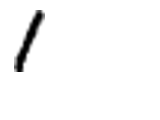

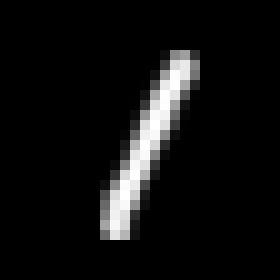

预测数字： 1
十类整数分数： [-25052  15776  -3625 -13068 -17985 -29175 -24344 -10668  -8516 -23528]


In [6]:
prepared = preprocess_digit_image(EXAMPLE_FILE)
result = model.forward(prepared.normalized_uint8)
display(Image.open(EXAMPLE_FILE))
display(Image.fromarray(prepared.normalized_uint8).resize((280, 280), Image.Resampling.NEAREST))
print("预测数字：", int(result.predictions[0]))
print("十类整数分数：", result.scores_int32[0])


接下来：A 阅读接口说明并用逐层标准答案验证硬件；C 将摄像头 ROI 接入同一预处理。